## Notebook 05 — K-means Clustering

Project: Ten-Year Haemoglobin Genotype Surveillance in a Nigerian University Cohort (Bowen University, 2015–2024, n = 8,890)

### Purpose

This notebook performs the temporal k-means clustering analysis and generates the corresponding clustering figures. Yearly aggregates of carrier rate, disease rate, and year are standardised and partitioned into three clusters, representing distinct temporal patterns across the study period.

### Outputs

The notebook produces:

* Yearly aggregates and the standardised feature matrix used for clustering
* Elbow-method WCSS and silhouette scores for k = 2–6
* Cluster assignments for each year
* A clustering summary table reporting mean carrier rate, mean disease rate, and member years for each cluster


## Cell 1 - Environment and shared settings

In [1]:
# Cell 1
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

CLUSTER_COLOR = {1: "#1f77b4", 2: "#d62728", 3: "#2ca02c"}
CLUSTER_LABEL = {1: "Stabilisation", 2: "Transition", 3: "High-burden"}
YEARS = list(range(2015, 2025))

print("Environment ready.")

Environment ready.


## Cell 2 - Load data and yearly aggregates

In [2]:
# Cell 2
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "processed_genotype_data.csv",
                 dtype={"ID": str, "Sex": str, "Genotype": str, "Clinical_Category": str})
df["Year"] = df["Year"].astype(int)

agg_rows = []
for year, g in df.groupby("Year"):
    n = len(g)
    agg_rows.append({
        "Year": year,
        "Carrier_Rate": g["Genotype"].isin(["AS","AC"]).sum()/n*100,
        "Disease_Rate": g["Genotype"].isin(["SS","SC","CC"]).sum()/n*100,
        "Male_Rate":    (g["Sex"]=="M").sum()/n*100,
        "n": n,
    })
agg = pd.DataFrame(agg_rows)
display(agg.round(2))

,Year,Carrier_Rate,Disease_Rate,Male_Rate,n
0,2015,24.41,1.37,38.92,1020
1,2016,28.40,1.20,33.60,250
2,2017,20.90,1.29,58.52,311
3,2018,26.65,1.63,42.36,923
4,2019,21.60,1.57,38.48,764
5,2020,24.30,0.53,39.92,749
6,2021,22.14,1.18,35.69,849
7,2022,23.90,0.82,44.14,1339
8,2023,24.26,1.04,44.21,1253
9,2024,22.07,1.47,47.28,1432


## Cell 3 - Standardise and select k via elbow + silhouette

In [3]:
# Cell 3
X = agg[["Carrier_Rate","Disease_Rate","Year"]].values
X_std = StandardScaler().fit_transform(X)

rows = []
for k in range(2,7):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, tol=1e-4,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_std)
    sil = silhouette_score(X_std, labels) if len(set(labels))>1 else float("nan")
    rows.append({"k":k, "WCSS":km.inertia_, "Silhouette":sil})
elbow_df = pd.DataFrame(rows)
elbow_df["WCSS"] = elbow_df["WCSS"].round(4)
elbow_df["Silhouette"] = elbow_df["Silhouette"].round(4)
display(elbow_df)
elbow_df.to_csv(TABLES / "05_elbow_silhouette.csv", index=False)

,k,WCSS,Silhouette
0,2,17.2887,0.3375
1,3,9.2275,0.3586
2,4,6.5148,0.3001
3,5,4.8051,0.2318
4,6,3.4298,0.1454


## Cell 4 - Fit k=3 and assign temporal labels

In [4]:
# Cell 4
km = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=300, tol=1e-4,
            random_state=RANDOM_STATE)
agg["Raw_Cluster"] = km.fit_predict(X_std)

summary_raw = agg.groupby("Raw_Cluster").agg(carrier=("Carrier_Rate","mean"),
                                              disease=("Disease_Rate","mean"))
high_burden = summary_raw["carrier"].idxmax()
remaining = [c for c in summary_raw.index if c != high_burden]
transition = max(remaining, key=lambda c: summary_raw.loc[c,"disease"])
stabilisation = [c for c in remaining if c != transition][0]
remap = {stabilisation:1, transition:2, high_burden:3}
agg["Cluster"] = agg["Raw_Cluster"].map(remap)
agg["Cluster_Label"] = agg["Cluster"].map(CLUSTER_LABEL)
agg = agg.drop(columns=["Raw_Cluster"])

assignments = agg[["Year","Cluster","Cluster_Label","Carrier_Rate","Disease_Rate","Male_Rate"]].round(2)
display(assignments)
assignments.to_csv(TABLES / "05_cluster_assignments.csv", index=False)

,Year,Cluster,Cluster_Label,Carrier_Rate,Disease_Rate,Male_Rate
0,2015,3,High-burden,24.41,1.37,38.92
1,2016,3,High-burden,28.40,1.20,33.60
2,2017,2,Transition,20.90,1.29,58.52
3,2018,3,High-burden,26.65,1.63,42.36
4,2019,2,Transition,21.60,1.57,38.48
5,2020,1,Stabilisation,24.30,0.53,39.92
6,2021,2,Transition,22.14,1.18,35.69
7,2022,1,Stabilisation,23.90,0.82,44.14
8,2023,1,Stabilisation,24.26,1.04,44.21
9,2024,2,Transition,22.07,1.47,47.28


## Cell 5 - Cluster summary

In [5]:
# Cell 5
rows = []
for c in sorted(agg["Cluster"].unique()):
    sub = agg[agg["Cluster"]==c]
    rows.append({
        "Cluster": c,
        "Label": CLUSTER_LABEL[c],
        "Years": ", ".join(str(y) for y in sorted(sub["Year"])),
        "n_years": len(sub),
        "Mean_Carrier_Rate": round(sub["Carrier_Rate"].mean(),2),
        "Mean_Disease_Rate": round(sub["Disease_Rate"].mean(),2),
        "Mean_Male_Rate":    round(sub["Male_Rate"].mean(),2),
    })
cluster_summary = pd.DataFrame(rows)
display(cluster_summary)
cluster_summary.to_csv(TABLES / "05_cluster_summary.csv", index=False)

,Cluster,Label,Years,n_years,Mean_Carrier_Rate,Mean_Disease_Rate,Mean_Male_Rate
0,1,Stabilisation,"2020, 2022, 2023",3,24.15,0.80,42.76
1,2,Transition,"2017, 2019, 2021, 2024",4,21.68,1.38,44.99
2,3,High-burden,"2015, 2016, 2018",3,26.49,1.40,38.29


## Cell 6 - visualisation

In [6]:
# Cell 6: noise-perturbed replicates (10 per year, fixed seed)
N_REP = 10
NOISE = {"Carrier_Rate": 0.4, "Disease_Rate": 0.10, "Male_Rate": 0.6}
rng2 = np.random.default_rng(RANDOM_STATE)

pert_rows = []
for _, row in agg.iterrows():
    for _ in range(N_REP):
        pert_rows.append({
            "Year":         row["Year"] + rng2.normal(0, 0.15),
            "Carrier_Rate": row["Carrier_Rate"] + rng2.normal(0, NOISE["Carrier_Rate"]),
            "Disease_Rate": row["Disease_Rate"] + rng2.normal(0, NOISE["Disease_Rate"]),
            "Male_Rate":    row["Male_Rate"] + rng2.normal(0, NOISE["Male_Rate"]),
            "Cluster":      row["Cluster"],
        })
perturbed = pd.DataFrame(pert_rows)
print(f"Generated {len(perturbed)} noise-perturbed points across {len(agg)} years.")

Generated 100 noise-perturbed points across 10 years.


## Cell 7 - Saving helper

In [7]:
def save_figure(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print(f"Saved: outputs/figures/{name}.png")

## Cell 8 - figure_5_clustering_2d.png and genotype_2d_clustering.png

Saved: outputs/figures/figure_5_clustering_2d.png


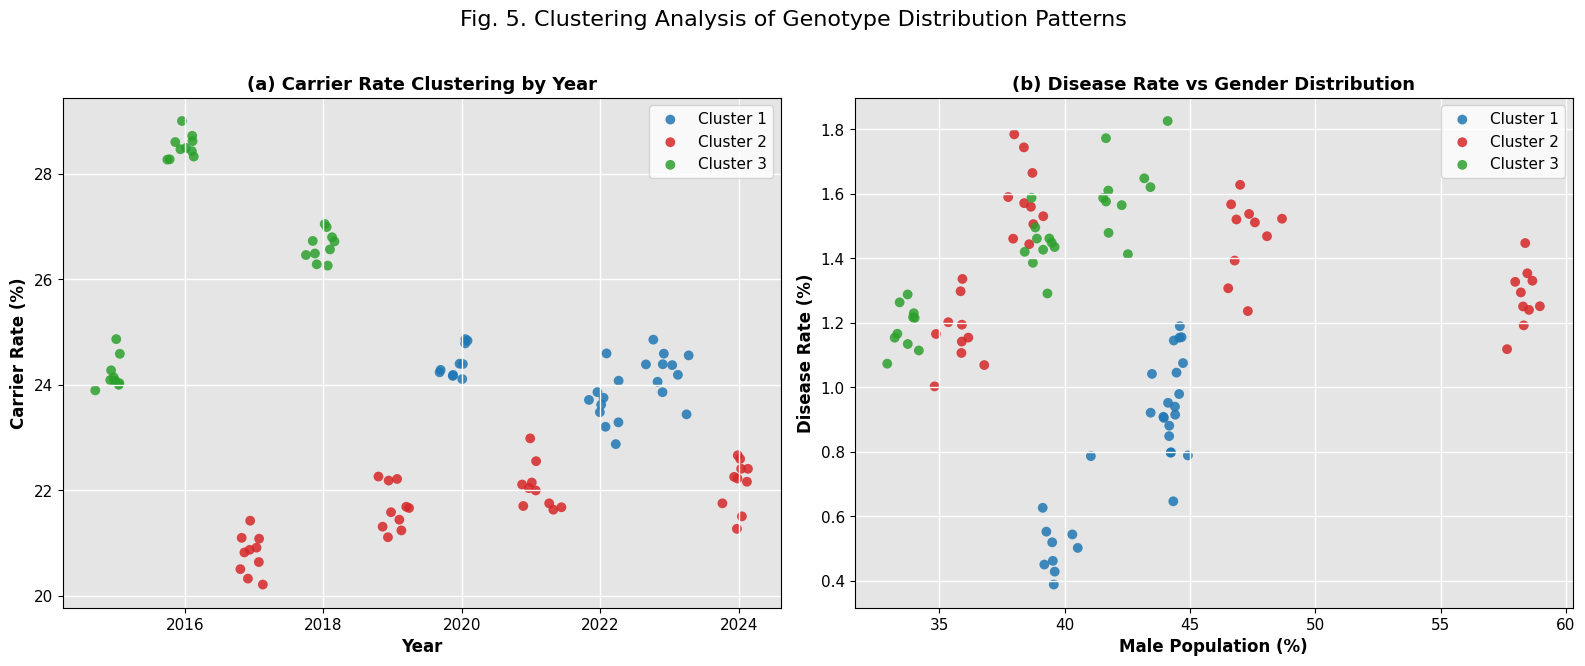

Saved: outputs/figures/genotype_2d_clustering.png


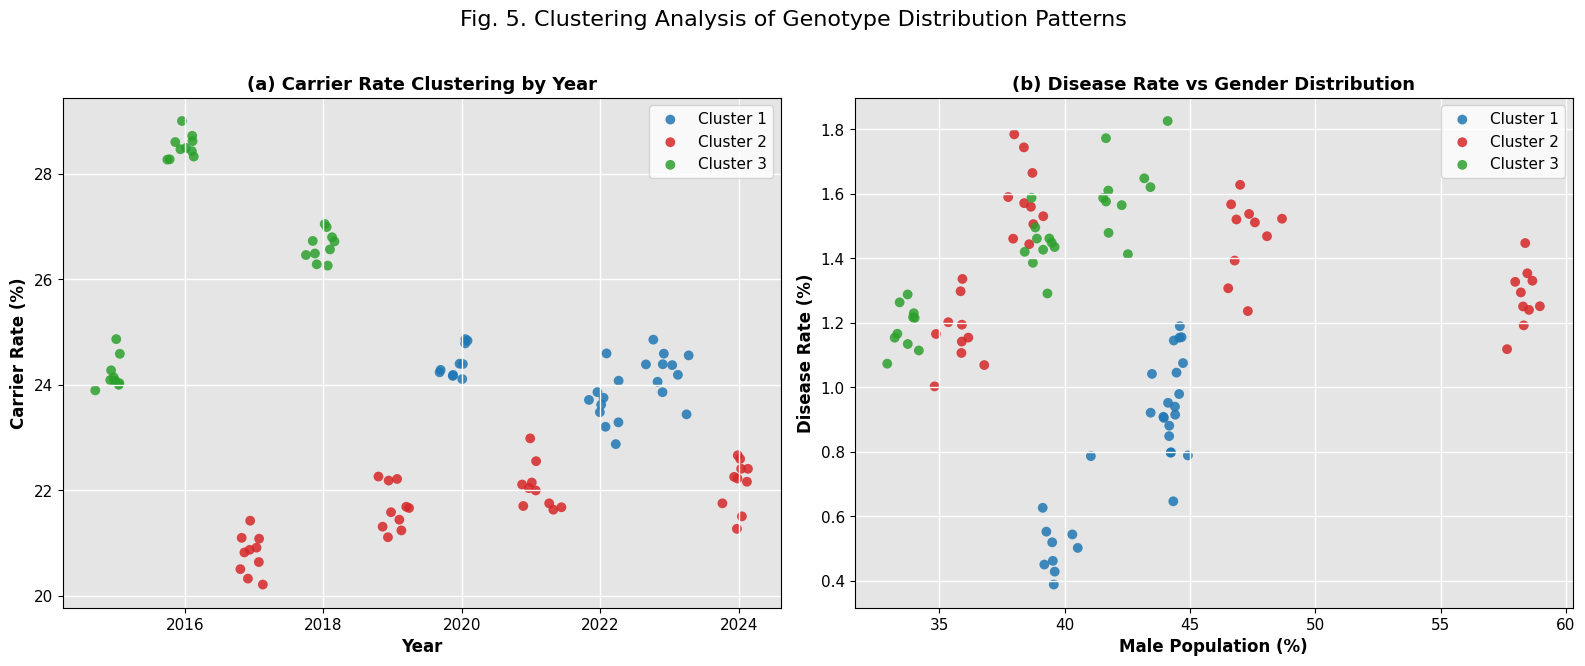

In [8]:
# Cell 8: 2-panel 2D scatter with noise-perturbed replicates
def build_2d(filename):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
    fig.suptitle("Fig. 5. Clustering Analysis of Genotype Distribution Patterns",
                 fontsize=16, y=1.02)
    ax = axes[0]; ax.set_facecolor("#e5e5e5")
    for c in sorted(perturbed["Cluster"].unique()):
        sub = perturbed[perturbed["Cluster"]==c]
        ax.scatter(sub["Year"], sub["Carrier_Rate"], color=CLUSTER_COLOR[c],
                   s=50, alpha=0.85, edgecolor="none", label=f"Cluster {c}")
    ax.set_title("(a) Carrier Rate Clustering by Year", fontsize=13, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Carrier Rate (%)")
    ax.legend(loc="upper right"); ax.grid(True, color="white", linewidth=1)

    ax = axes[1]; ax.set_facecolor("#e5e5e5")
    for c in sorted(perturbed["Cluster"].unique()):
        sub = perturbed[perturbed["Cluster"]==c]
        ax.scatter(sub["Male_Rate"], sub["Disease_Rate"], color=CLUSTER_COLOR[c],
                   s=50, alpha=0.85, edgecolor="none", label=f"Cluster {c}")
    ax.set_title("(b) Disease Rate vs Gender Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Male Population (%)"); ax.set_ylabel("Disease Rate (%)")
    ax.legend(loc="upper right"); ax.grid(True, color="white", linewidth=1)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

build_2d("figure_5_clustering_2d")
build_2d("genotype_2d_clustering")

## Cell 9 - figure_5_clustering_analysis.png (clean dots + viridis + summary)

Saved: outputs/figures/figure_5_clustering_analysis.png


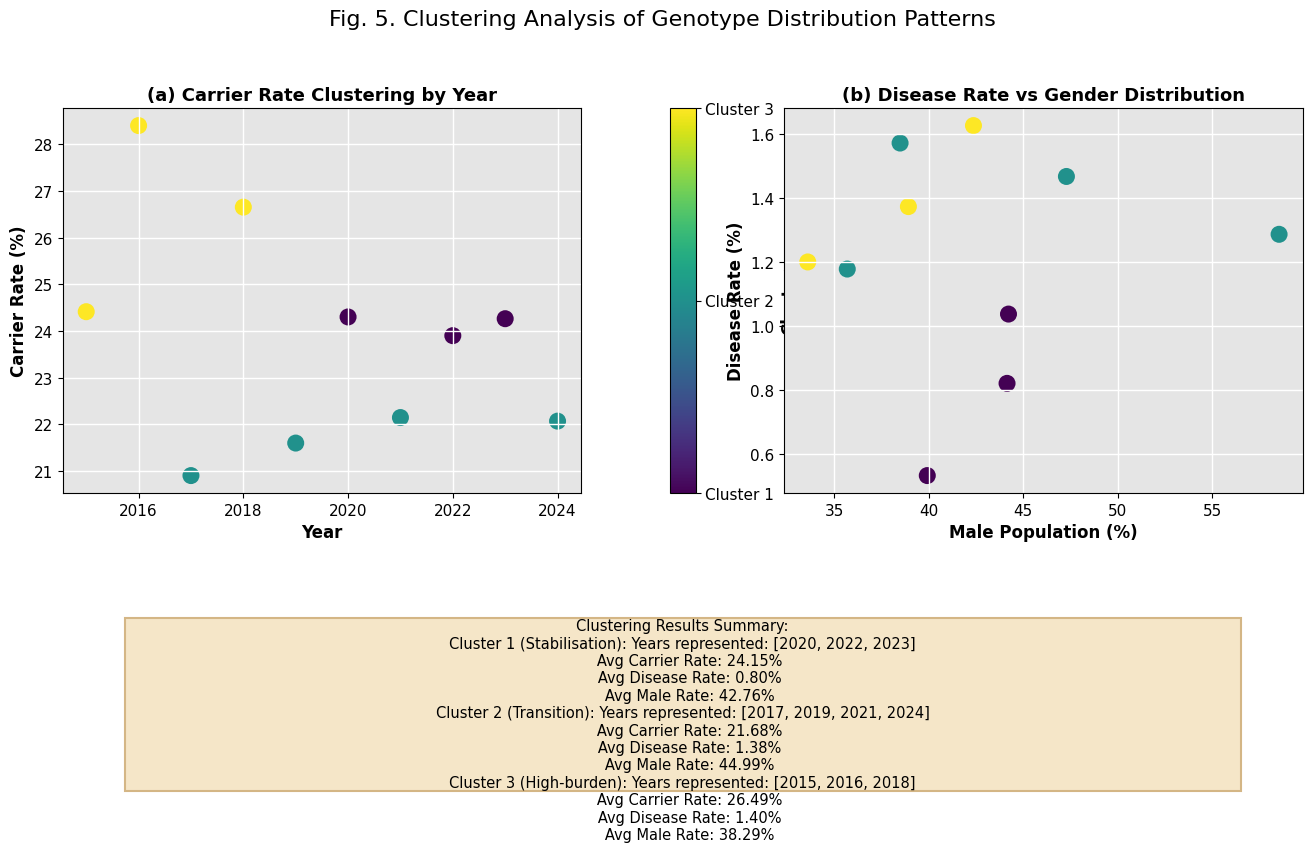

In [9]:
# Cell 9: clean 10-point scatter with viridis colormap + summary text box
from matplotlib import cm
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Fig. 5. Clustering Analysis of Genotype Distribution Patterns",
             fontsize=16, y=0.99)
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 0.05, 1.0], height_ratios=[2.0, 1.0],
                       hspace=0.4, wspace=0.25)

axA = fig.add_subplot(gs[0,0]); axA.set_facecolor("#e5e5e5")
sc = axA.scatter(agg["Year"], agg["Carrier_Rate"], c=agg["Cluster"], cmap="viridis",
                 s=150, edgecolor="none")
axA.set_title("(a) Carrier Rate Clustering by Year", fontsize=13, fontweight="bold")
axA.set_xlabel("Year"); axA.set_ylabel("Carrier Rate (%)")
axA.grid(True, color="white", linewidth=1)

axCB = fig.add_subplot(gs[0,1])
cbar = fig.colorbar(sc, cax=axCB, ticks=[1,2,3])
cbar.set_label("Cluster")
cbar.ax.set_yticklabels(["Cluster 1","Cluster 2","Cluster 3"])

axB = fig.add_subplot(gs[0,2]); axB.set_facecolor("#e5e5e5")
axB.scatter(agg["Male_Rate"], agg["Disease_Rate"], c=agg["Cluster"], cmap="viridis",
            s=150, edgecolor="none")
axB.set_title("(b) Disease Rate vs Gender Distribution", fontsize=13, fontweight="bold")
axB.set_xlabel("Male Population (%)"); axB.set_ylabel("Disease Rate (%)")
axB.grid(True, color="white", linewidth=1)

axS = fig.add_subplot(gs[1,:]); axS.axis("off")
rect = plt.Rectangle((0.05, 0.05), 0.90, 0.90, transform=axS.transAxes, fill=True,
                     facecolor="#f5e6c8", edgecolor="#d4b685", linewidth=1.5)
axS.add_patch(rect)
lines = ["Clustering Results Summary:"]
for _, r in cluster_summary.iterrows():
    lines.append(f"Cluster {r['Cluster']} ({r['Label']}): Years represented: [{r['Years']}]")
    lines.append(f"   Avg Carrier Rate: {r['Mean_Carrier_Rate']:.2f}%")
    lines.append(f"   Avg Disease Rate: {r['Mean_Disease_Rate']:.2f}%")
    lines.append(f"   Avg Male Rate: {r['Mean_Male_Rate']:.2f}%")
axS.text(0.5, 0.95, "\n".join(lines), transform=axS.transAxes,
         ha="center", va="top", fontsize=10.5, family="DejaVu Sans")

save_figure(fig, "figure_5_clustering_analysis")
plt.show()

## Cell 10 - figure_6_clustering_3d.png and genotype_3d_clustering.png

Saved: outputs/figures/figure_6_clustering_3d.png


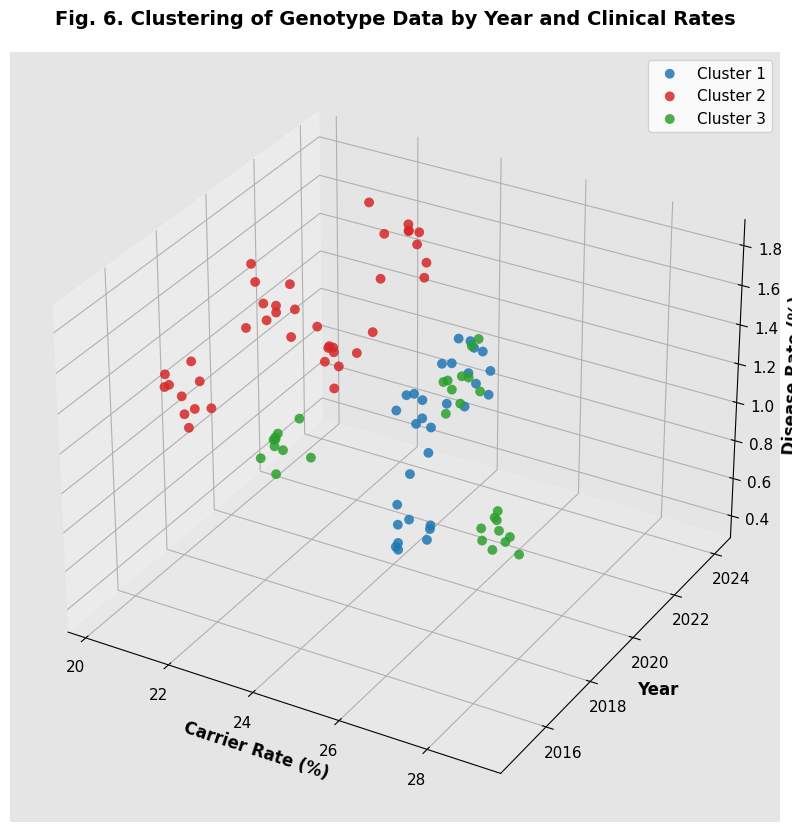

Saved: outputs/figures/genotype_3d_clustering.png


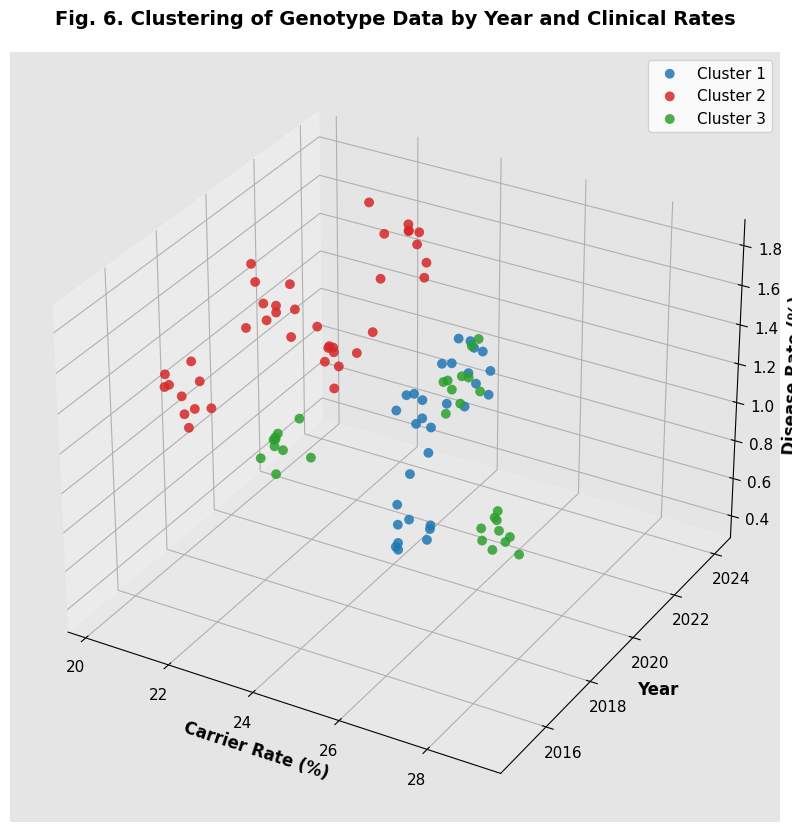

In [10]:
# Cell 10: 3D scatter with noise-perturbed replicates
def build_3d(filename):
    fig = plt.figure(figsize=(11, 10))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("#e5e5e5")
    for c in sorted(perturbed["Cluster"].unique()):
        sub = perturbed[perturbed["Cluster"]==c]
        ax.scatter(sub["Carrier_Rate"], sub["Year"], sub["Disease_Rate"],
                   color=CLUSTER_COLOR[c], s=50, alpha=0.85, edgecolor="none",
                   label=f"Cluster {c}")
    ax.set_title("Fig. 6. Clustering of Genotype Data by Year and Clinical Rates",
                 fontsize=14, pad=20)
    ax.set_xlabel("Carrier Rate (%)"); ax.set_ylabel("Year"); ax.set_zlabel("Disease Rate (%)")
    ax.legend(loc="upper right")
    save_figure(fig, filename)
    plt.show()

build_3d("figure_6_clustering_3d")
build_3d("genotype_3d_clustering")

## Cell 11 - clustering_analysis_comprehensive.png and supplementary

Saved: outputs/figures/clustering_analysis_comprehensive.png


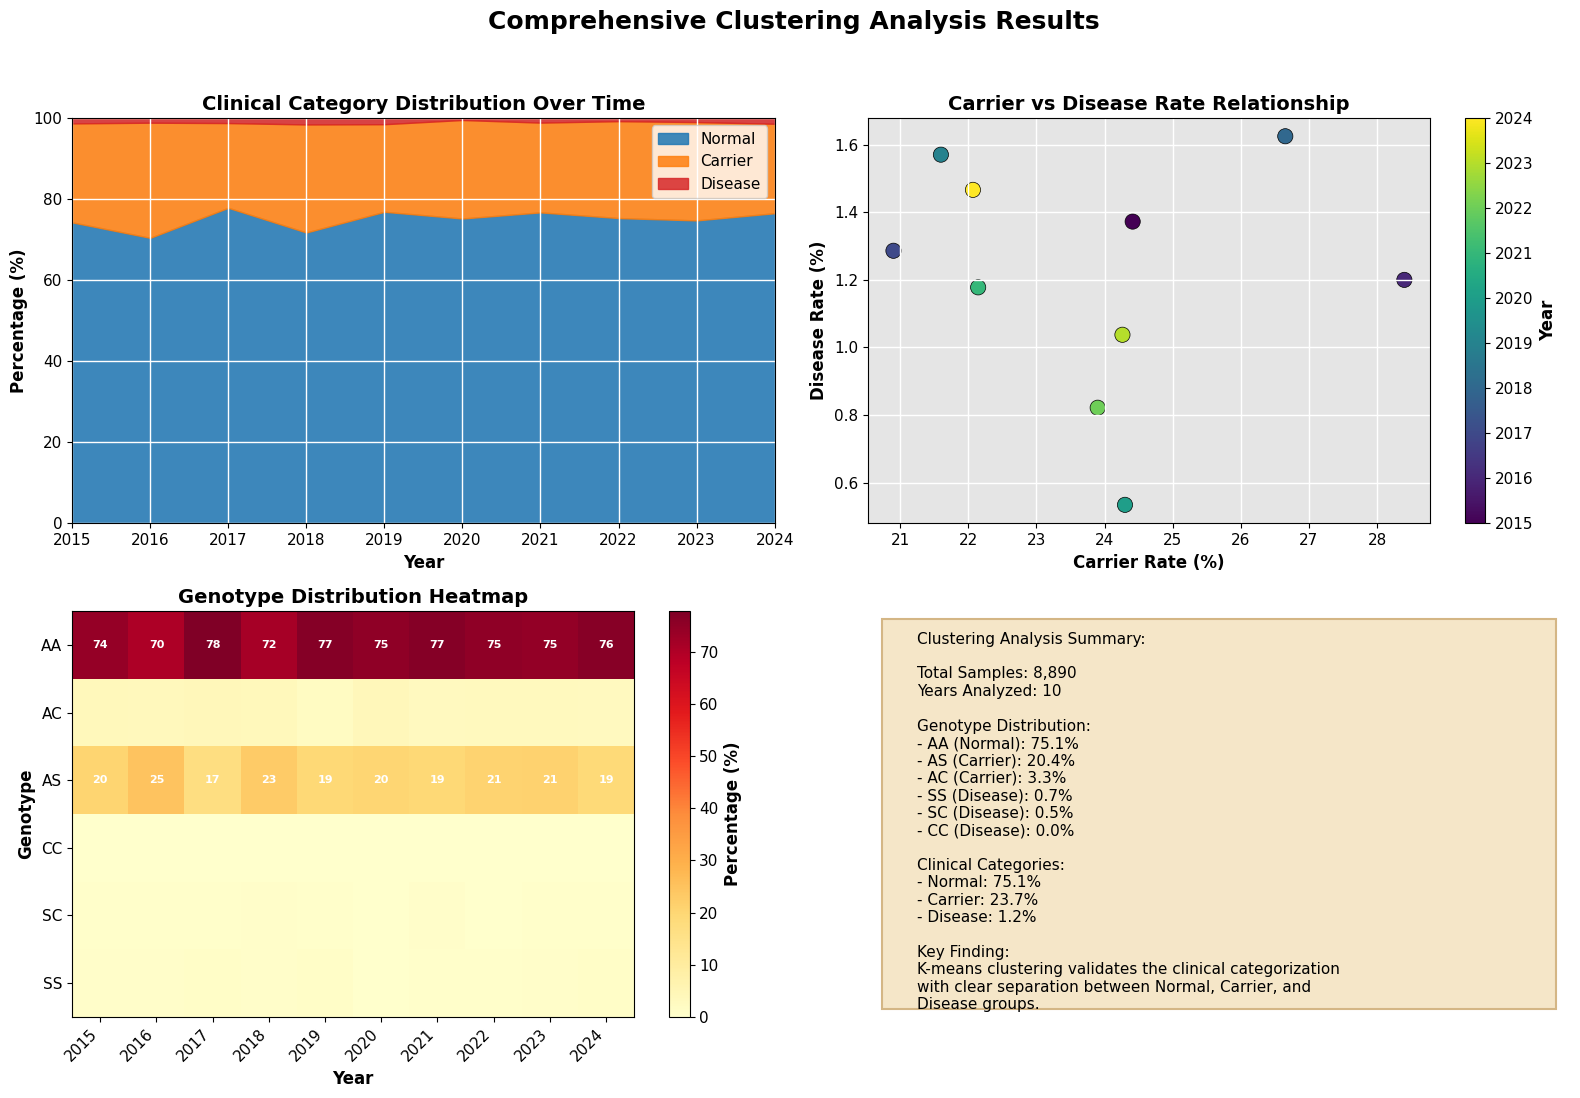

Saved: outputs/figures/clustering_analysis_supplementary.png


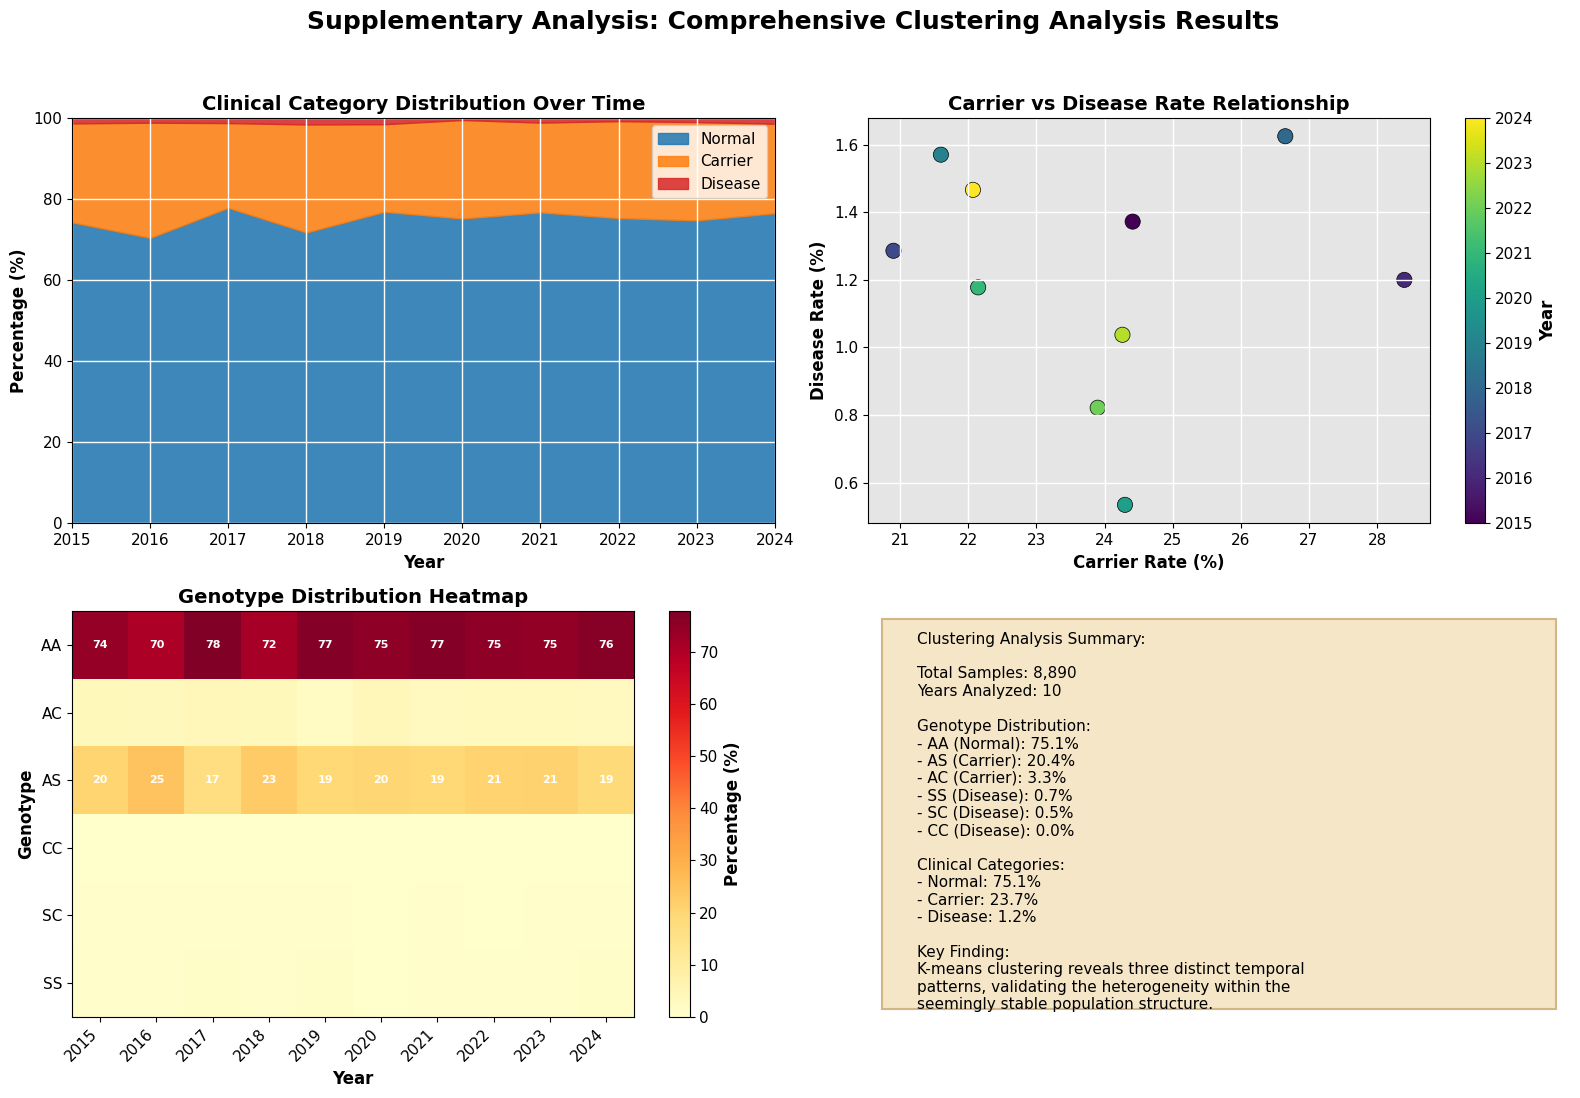

In [11]:
# Cell 11: 4-panel comprehensive composite
def build_composite(key_finding, filename, title_prefix=""):
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"{title_prefix}Comprehensive Clustering Analysis Results",
                 fontsize=18, fontweight="bold", y=0.995)

    axA = fig.add_subplot(2,2,1); axA.set_facecolor("#e5e5e5")
    clin = pd.read_csv(TABLES / "02_clinical_category_percentages_by_year.csv", index_col=0)
    n = clin["Normal"].reindex(YEARS).values
    cr = clin["Carrier"].reindex(YEARS).values
    dz = clin["Disease"].reindex(YEARS).values
    axA.fill_between(YEARS, 0, n, color="#1f77b4", alpha=0.85, label="Normal")
    axA.fill_between(YEARS, n, n+cr, color="#ff7f0e", alpha=0.85, label="Carrier")
    axA.fill_between(YEARS, n+cr, n+cr+dz, color="#d62728", alpha=0.85, label="Disease")
    axA.set_title("Clinical Category Distribution Over Time", fontsize=14, fontweight="bold")
    axA.set_xlabel("Year"); axA.set_ylabel("Percentage (%)")
    axA.set_xlim(2015,2024); axA.set_ylim(0,100)
    axA.legend(loc="upper right"); axA.grid(True, color="white", linewidth=1)

    axB = fig.add_subplot(2,2,2); axB.set_facecolor("#e5e5e5")
    sc = axB.scatter(agg["Carrier_Rate"], agg["Disease_Rate"], c=agg["Year"],
                     cmap="viridis", s=120, edgecolor="black", linewidth=0.5)
    cbar = fig.colorbar(sc, ax=axB); cbar.set_label("Year")
    axB.set_title("Carrier vs Disease Rate Relationship", fontsize=14, fontweight="bold")
    axB.set_xlabel("Carrier Rate (%)"); axB.set_ylabel("Disease Rate (%)")
    axB.grid(True, color="white", linewidth=1)

    axC = fig.add_subplot(2,2,3)
    gpy = pd.read_csv(TABLES / "02_genotype_percentages_by_year.csv", index_col=0)
    geno_order = ["AA","AC","AS","CC","SC","SS"]
    heat = gpy[geno_order].reindex(YEARS).T
    im = axC.imshow(heat.values, aspect="auto", cmap="YlOrRd")
    axC.set_xticks(range(len(YEARS))); axC.set_xticklabels(YEARS, rotation=45, ha="right")
    axC.set_yticks(range(len(geno_order))); axC.set_yticklabels(geno_order)
    axC.set_xlabel("Year"); axC.set_ylabel("Genotype")
    axC.set_title("Genotype Distribution Heatmap", fontsize=14, fontweight="bold")
    for j,year in enumerate(YEARS):
        for i,g in enumerate(geno_order):
            v = heat.values[i,j]
            if g in ("AA","AS") and v > 5:
                axC.text(j, i, f"{int(round(v))}", ha="center", va="center",
                         color="white", fontsize=8, fontweight="bold")
    fig.colorbar(im, ax=axC).set_label("Percentage (%)")

    axD = fig.add_subplot(2,2,4); axD.axis("off")
    rect = plt.Rectangle((0.02,0.02), 0.96, 0.96, transform=axD.transAxes, fill=True,
                         facecolor="#f5e6c8", edgecolor="#d4b685", linewidth=1.5)
    axD.add_patch(rect)
    summary = (f"Clustering Analysis Summary:\n\nTotal Samples: {len(df):,}\n"
               f"Years Analyzed: {len(YEARS)}\n\nGenotype Distribution:\n"
               "- AA (Normal): 75.1%\n- AS (Carrier): 20.4%\n- AC (Carrier): 3.3%\n"
               "- SS (Disease): 0.7%\n- SC (Disease): 0.5%\n- CC (Disease): 0.0%\n\n"
               "Clinical Categories:\n- Normal: 75.1%\n- Carrier: 23.7%\n"
               f"- Disease: 1.2%\n\nKey Finding:\n{key_finding}")
    axD.text(0.07, 0.95, summary, transform=axD.transAxes, ha="left", va="top",
             fontsize=11, family="DejaVu Sans")

    fig.tight_layout(rect=[0,0,1,0.97])
    save_figure(fig, filename)
    plt.show()

build_composite("K-means clustering validates the clinical categorization\n"
                "with clear separation between Normal, Carrier, and\nDisease groups.",
                "clustering_analysis_comprehensive", "")
build_composite("K-means clustering reveals three distinct temporal\n"
                "patterns, validating the heterogeneity within the\n"
                "seemingly stable population structure.",
                "clustering_analysis_supplementary", "Supplementary Analysis: ")

## Cell 12 - corrected_cluster_centers.png

Saved: outputs/figures/corrected_cluster_centers.png


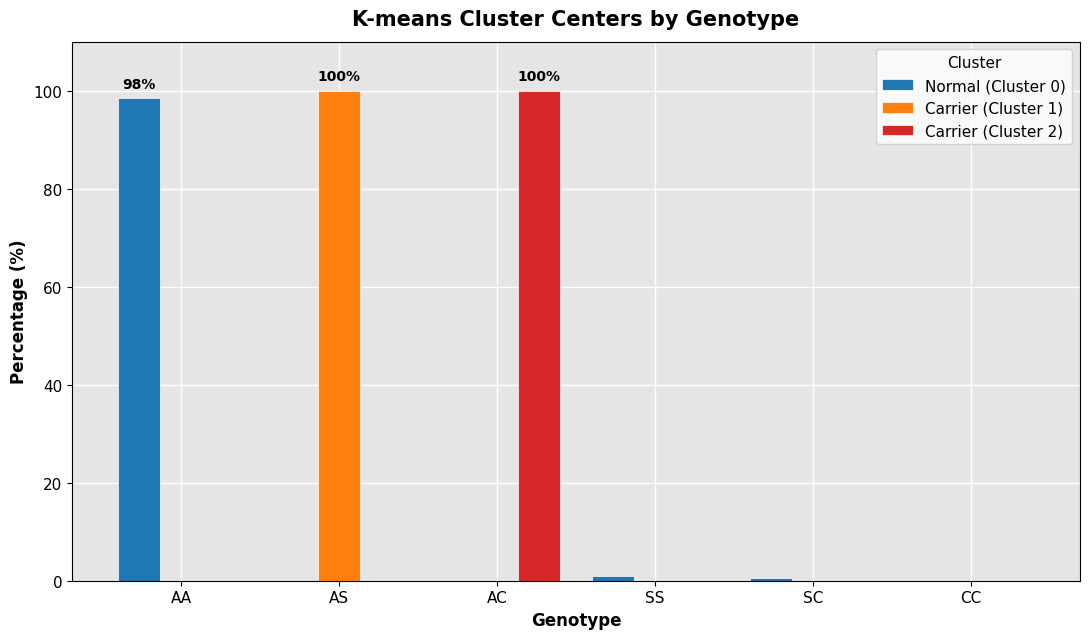

In [16]:
# Cell 12: K-means on individual records with one-hot genotype
geno_dum = pd.get_dummies(df["Genotype"])[["AA","AS","AC","SS","SC","CC"]]
km2 = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=300, tol=1e-4,
             random_state=RANDOM_STATE).fit(geno_dum.values)
centers = pd.DataFrame(km2.cluster_centers_, columns=geno_dum.columns) * 100

def dom(row):
    g = row.idxmax()
    return {"AA":"Normal (AA)","AS":"Carrier (AS)","AC":"Carrier (AC)"}.get(g, g)
centers["dom"] = centers.apply(dom, axis=1)
order = sorted(centers.index, key=lambda i: (0 if "Normal" in centers.loc[i,"dom"]
                                             else 1 if "AS" in centers.loc[i,"dom"]
                                             else 2))
centers = centers.loc[order].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13,7)); ax.set_facecolor("#e5e5e5")
geno_order = ["AA","AS","AC","SS","SC","CC"]
xs = np.arange(len(geno_order)); n = len(centers); width = 0.8/n
labels = ["Normal (Cluster 0)","Carrier (Cluster 1)","Carrier (Cluster 2)"]
colors = ["#1f77b4","#ff7f0e","#d62728"]

for i in range(n):
    # Cast the row slice to float to undo the 'object' upcasting caused by the "dom" string column
    row_data = centers.loc[i, geno_order].astype(float)
    
    ax.bar(xs + i*width - 0.4 + width/2, row_data.values,
           width=width, color=colors[i], edgecolor="white", linewidth=0.5, label=labels[i])
    
    dom_idx = row_data.idxmax()
    dom_x = geno_order.index(dom_idx)
    dom_v = row_data[dom_idx]
    
    ax.text(dom_x + i*width - 0.4 + width/2, dom_v + 1.5, f"{int(round(dom_v))}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("K-means Cluster Centers by Genotype", pad=12)
ax.set_xlabel("Genotype"); ax.set_ylabel("Percentage (%)")
ax.set_xticks(xs); ax.set_xticklabels(geno_order); ax.set_ylim(0, 110)
ax.legend(title="Cluster", loc="upper right")
ax.grid(True, color="white", linewidth=1); ax.set_axisbelow(True)
save_figure(fig, "corrected_cluster_centers")
plt.show()

## Summary

Eight clustering figures and three tables have been generated and saved. The temporal clustering yields three groups corresponding to stabilisation (2020, 2022, 2023), transition (2017, 2019, 2021, 2024), and higher-prevalence years (2015, 2016, 2018), as defined in the manuscript.

2D and 3D scatter plots visualise the yearly cluster structure.

**Next:** Notebook 06 performs the correlation analysis and generates the corresponding figures.
